In [1]:
import pandas as pd
df = pd.read_csv('C:\\Users\\akhil\\OneDrive\\Desktop\\Online Retail Dataset\\online_retail.csv', encoding='ISO-8859-1')
print(df.head())



  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [ ]:
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
 8   Totalprice   401604 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.6+ MB
None
            Quantity                    InvoiceDate      UnitPrice  \
count  401604.000000                         401604  401604.000000   
mean       12.183273  2011-07-10 12:08:23.848567552       3.474064   
min    -80995.000000            2010-12-01 08:26

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df=df.dropna()

In [11]:
df=df.drop_duplicates()

In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
df['Totalprice'] = df['Quantity'] * df['UnitPrice']

In [16]:
df=df[df['Quantity']>0]
df=df[df['UnitPrice']>0]

In [17]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   Totalprice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB
None
            Quantity                    InvoiceDate      UnitPrice  \
count  392692.000000                         392692  392692.000000   
mean       13.119702  2011-07-10 19:13:07.771892480       3.125914   
min         1.000000            2010-12-01 08:26

In [18]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [19]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Totalprice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

Top Customers(High Spenders)

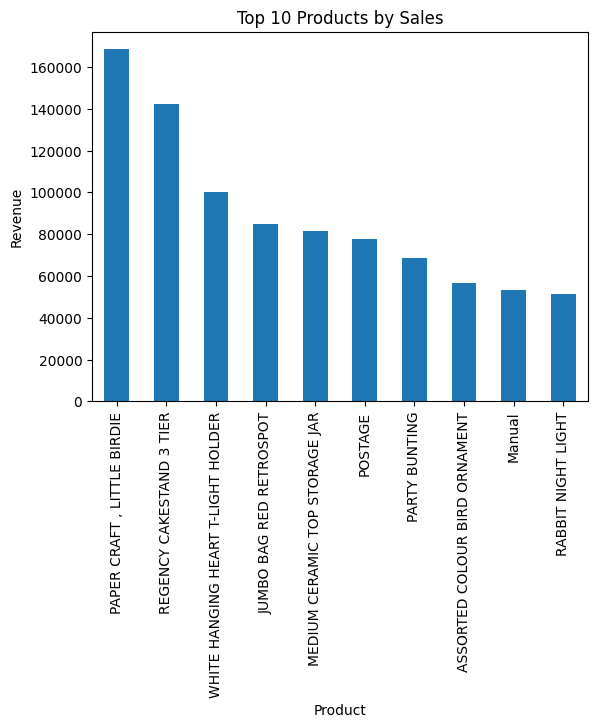

In [29]:
top_products = (
    df.groupby('Description')['Totalprice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind='bar')
import matplotlib.pyplot as plt

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

Monthly Sales Trend

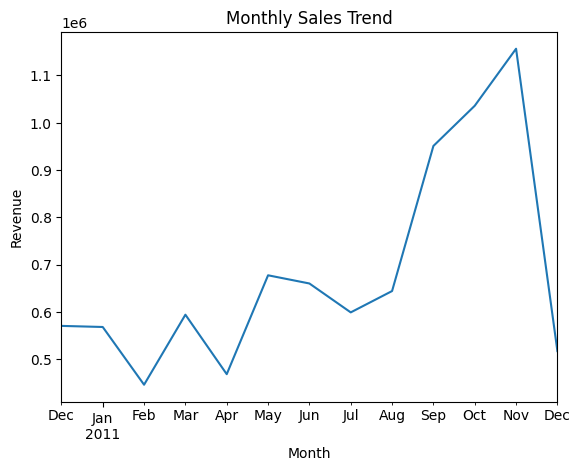

In [30]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Totalprice'].sum()
monthly_sales.plot(kind='line')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Top Countries Revenue

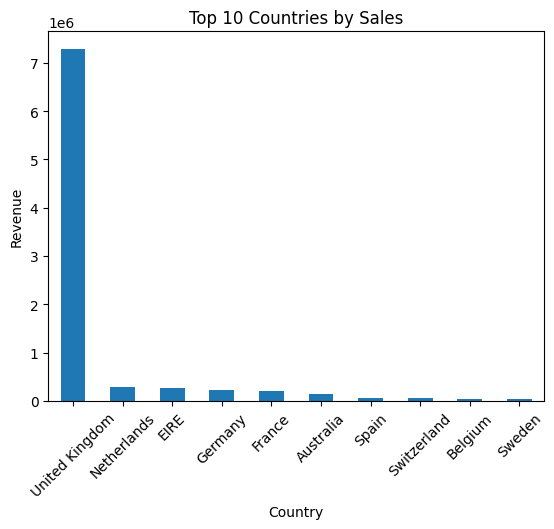

In [32]:
country_sales = (
    df.groupby('Country')['Totalprice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales.plot(kind='bar')
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Top Customers(high value Customers)


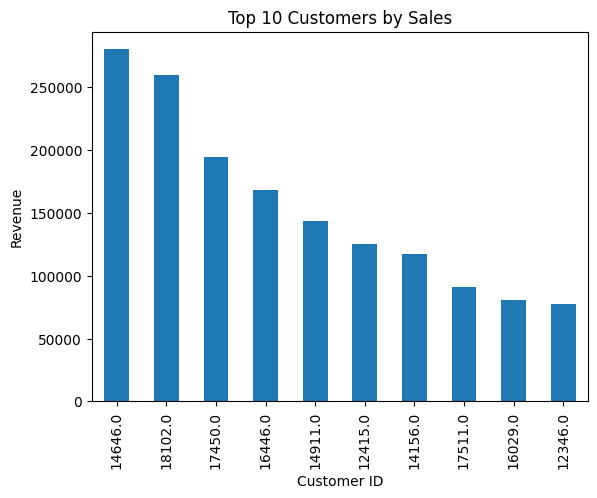

In [33]:
top_customers = (
    df.groupby('CustomerID')['Totalprice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

Correlation heatmap

<function matplotlib.pyplot.show(close=None, block=None)>

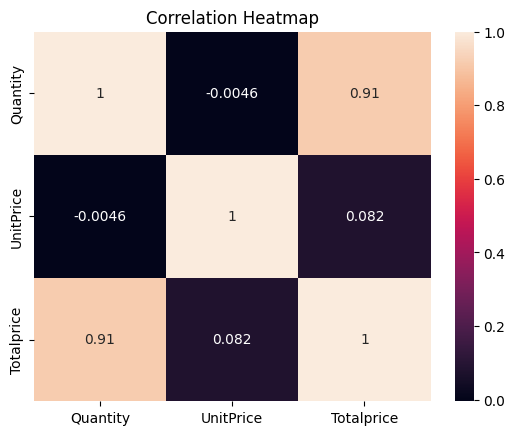

In [37]:
corr = df[['Quantity','UnitPrice','Totalprice']].corr()
sns.heatmap(corr,annot=True)

plt.title("Correlation Heatmap")
plt.show

In [6]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="AA7760khil@#",
    database="ecommerce"
)

cursor = conn.cursor()

print("Connected successfully!")

Connected successfully!


In [2]:
import pandas as pd
df=pd.read_csv('C:\\Users\\akhil\\OneDrive\\Desktop\\Online Retail Dataset\\online_retail.csv', encoding='ISO-8859-1')

In [3]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Totalprice'] = df['Quantity'] * df['UnitPrice']

In [4]:
df.to_csv('cleaned_online_retail.csv', index=False)

In [14]:
customer_data = df.groupby('CustomerID')['Totalprice'].sum().reset_index()
print(customer_data.head())

   CustomerID  Totalprice
0     12346.0        0.00
1     12347.0     4310.00
2     12348.0     1797.24
3     12349.0     1757.55
4     12350.0      334.40


In [16]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
customer_data['Cluster'] = kmeans.fit_predict(customer_data[['Totalprice']])

In [17]:
customer_data.groupby('Cluster')['Totalprice'].mean()

Cluster
0      1342.587756
1    187322.170000
2     35713.422222
3    114381.037500
4    267963.755000
Name: Totalprice, dtype: float64

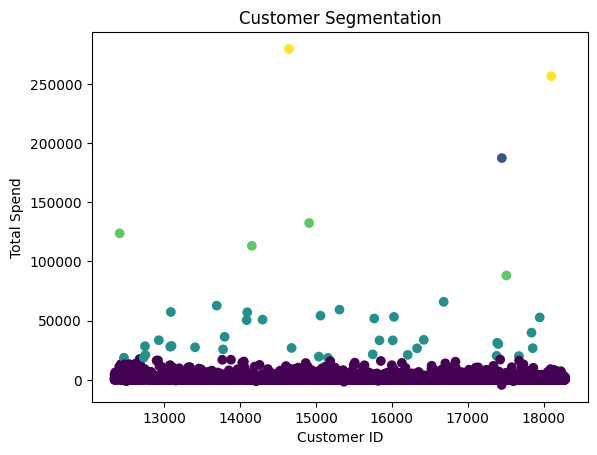

In [19]:
import matplotlib.pyplot as plt
plt.scatter(customer_data['CustomerID'],
            customer_data['Totalprice'],
            c=customer_data['Cluster'])

plt.title("Customer Segmentation")
plt.xlabel("Customer ID")
plt.ylabel("Total Spend")
plt.show()

Label Cluster


In [20]:
def label_cluster(x):
    if x == 0:
        return "Low Spenders"
    elif x == 1:
        return "Medium Spenders"
    else:
        return "High Spenders"
    
    customer_data['Segment'] = customer_data['Cluster'].apply(label_cluster)
print(customer_data.head())

   CustomerID  Totalprice  Cluster
0     12346.0        0.00        0
1     12347.0     4310.00        0
2     12348.0     1797.24        0
3     12349.0     1757.55        0
4     12350.0      334.40        0


Create Customer product Matrix

In [21]:
customer_product = df.pivot_table(
    index = 'CustomerID',
    columns = 'Description',
    values = 'Totalprice',
    fill_value=0
)

print(customer_product.shape)

(4372, 3896)


Apply similarity


In [22]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(customer_product)
print(similarity.shape)

(4372, 4372)


In [23]:
import pandas as pd
similarity_df = pd.DataFrame(
    similarity,
    index = customer_product.index,
    columns = customer_product.index
)

In [25]:
def recommend(customer_id):
    similar_customers = similarity_df[customer_id].sort_values(ascending=False)
    return similar_customers.iloc[1:6]

print(recommend(customer_data['CustomerID'].iloc[0]))

CustomerID
12347.0    0.0
12348.0    0.0
12349.0    0.0
12350.0    0.0
12352.0    0.0
Name: 12346.0, dtype: float64
